# Day 116 — GridSearchCV Depth + Hyperparameter Tuning
**Month 6 | Week 6 | ShopEase 300-row Dataset (seed=42)**

---

| Section | Content |
|---------|---------|
| 1 | Raw Data Setup |
| 2 | Practice Guide — Tasks A → E + ★ Bonus |
| 3 | Concept Notes |
| 4 | Answer Key |
| 5 | Scoring Rubric |

**What you'll build today:**  
A systematic hyperparameter tuning workflow — using GridSearchCV and RandomizedSearchCV inside a full Pipeline — and learn to read a `cv_results_` table like a professional. You will also understand *why* certain parameters move performance, not just *which* values win.


---
## Section 1 — Raw Data Setup
> ⚠️ Run this cell once. Never modify it.

In [2]:
# Section 1 — Raw Data (DO NOT MODIFY)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, learning_curve
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split

np.random.seed(42)
n = 300

data = pd.DataFrame({
    "customer_id":    range(1001, 1001 + n),
    "tenure_months":  np.random.randint(1, 73, n),
    "monthly_spend":  np.round(np.random.uniform(200, 5000, n), 2),
    "num_products":   np.random.randint(1, 6, n),
    "support_calls":  np.random.randint(0, 11, n),
    "region":         np.random.choice(["North","South","East","West"], n),
    "plan_type":      np.random.choice(["Basic","Standard","Premium"], n),
})

# Churn logic (same seed=42 as all Month 6 days)
churn_score = (
    -0.03 * data["tenure_months"]
    + 0.0002 * data["monthly_spend"]
    - 0.1  * data["num_products"]
    + 0.15 * data["support_calls"]
)
churn_prob = 1 / (1 + np.exp(-churn_score))
data["churn"] = (churn_prob > 0.5).astype(int)

X = data.drop(columns=["customer_id","churn"])
y = data["churn"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Dataset shape:", data.shape)
print("Churn rate:", round(y.mean()*100, 1), "%")
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])
print("\nFeature dtypes:")
print(X.dtypes)
print("\nFirst 3 rows:")
data.head(3)


Dataset shape: (300, 8)
Churn rate: 45.3 %
Train size: 240 | Test size: 60

Feature dtypes:
tenure_months      int32
monthly_spend    float64
num_products       int32
support_calls      int32
region            object
plan_type         object
dtype: object

First 3 rows:


,customer_id,tenure_months,monthly_spend,num_products,support_calls,region,plan_type,churn
0,1001,52,2853.54,2,5,East,Standard,0
1,1002,15,1623.25,4,6,South,Basic,1
2,1003,72,2214.95,1,2,North,Basic,0


---
## Section 3 — Concept Notes

### What is Hyperparameter Tuning?
A model has two kinds of parameters:
- **Learned parameters** — weights/thresholds the model finds from data (e.g. tree splits)
- **Hyperparameters** — settings *you* choose before training (e.g. how many trees, max tree depth)

Tuning = systematically searching for the hyperparameter combination that maximises your validation metric.

---

### GridSearchCV — Exhaustive Search

```
GridSearchCV(estimator, param_grid, cv=5, scoring='f1')
```

| Concept | Meaning |
|---------|---------|
| `param_grid` | Dict of parameter names → list of values to try |
| `cv=5` | Each combo is evaluated 5 times (5-fold CV) |
| `scoring` | Metric used to rank combos |
| `refit=True` | After search, retrain best combo on full training set |
| `n_jobs=-1` | Use all CPU cores |

**Total fits = (combinations) × (folds)**  
Example: 3 values × 3 values × 5 folds = **45 fits**

---

### RandomizedSearchCV — Probabilistic Search

When the grid is large, exhaustive search is expensive. `RandomizedSearchCV` samples `n_iter` random combinations instead.

```
RandomizedSearchCV(estimator, param_distributions, n_iter=20, cv=5)
```

- `param_distributions` can be a dict of **lists** or **scipy distributions**
- Rule of thumb: use RandomizedSearch when total grid > 100 combinations

---

### Inside `cv_results_`

After fitting, `search.cv_results_` is a dict with one row per combination:

| Key | Meaning |
|-----|---------|
| `mean_test_score` | Average CV metric across folds |
| `std_test_score` | Variance (high std = unstable model) |
| `rank_test_score` | 1 = best |
| `params` | The hyperparameter combo |
| `mean_fit_time` | How long each combo took |

**Business translation:** You're not just picking the best score — you want low `std_test_score` (reliability) + high `mean_test_score` (performance). A model that scores 0.72 ± 0.01 beats one that scores 0.73 ± 0.08 in production.

---

### Key Hyperparameters — Random Forest

| Parameter | Effect on Model |
|-----------|----------------|
| `n_estimators` | More trees = more stable, slower; diminishing returns ~200 |
| `max_depth` | Limits tree depth; lower = less overfit, more bias |
| `min_samples_split` | Higher = more pruning, less overfit |
| `min_samples_leaf` | Minimum samples at leaf; controls smoothness |
| `max_features` | Fraction of features per split; lower = more diverse trees |

---

### Pipeline + GridSearchCV Integration

When your estimator is a Pipeline, parameter names use `stepname__param` syntax:

```python
pipe = Pipeline([("pre", preprocessor), ("clf", RandomForestClassifier())])

param_grid = {
    "clf__n_estimators": [100, 200],
    "clf__max_depth": [5, 10, None],
}
```

This is the **correct professional pattern** — the search tunes the entire pipeline end-to-end, including preprocessing.

---

### Interview Answer
> *"How do you tune a machine learning model?"*

> "I define a hyperparameter grid, wrap my Pipeline in GridSearchCV with stratified K-fold CV, and rank combinations by F1 (or the business metric). I read `cv_results_` to check both mean score *and* standard deviation — a low-variance model is more trustworthy in production than a marginally higher-scoring but unstable one. For large grids I switch to RandomizedSearchCV with `n_iter=20–50`."


---
## Section 2 — Practice Guide

**Rules:**
1. Write a plain-English comment above every code block before writing the code
2. NRA = Number + Reason + Action (required wherever stated)
3. All tasks build on Section 1 raw data — do not regenerate data
4. Run all cells top-to-bottom before submission

---

### Task A — Baseline Pipeline (No Tuning)
*Earn 18 pts*

**A1 (5 pts):** Build a full Pipeline with:
- `ColumnTransformer`: StandardScaler on numeric cols, OneHotEncoder on categorical cols
- Classifier: `RandomForestClassifier(random_state=42)`  
Fit on train set. Print: Accuracy, F1, ROC-AUC on test set.  
*This is your baseline — every tuned model must beat it.*

**A2 (5 pts):** Print `pipe.named_steps` and list every step name + its type.  
Then write: *"If a client asks to retrain this model next quarter, what is the minimum code change required?"* (1–2 sentences)

**A3 (8 pts):** Using only the baseline pipeline (no new fitting), print:  
- Confusion matrix  
- Classification report  
Write a 3-line NRA interpretation: one line per metric (Accuracy, F1, ROC-AUC).  
Format: `[Metric]: [Value] — because [Reason] — action: [Action]`

---

### Task B — GridSearchCV: Small Grid
*Earn 20 pts*

**B1 (8 pts):** Define a `param_grid` with:
```
clf__n_estimators: [50, 100, 200]
clf__max_depth: [5, 10, None]
```
Run `GridSearchCV` (cv=5, scoring='f1', n_jobs=-1, refit=True).  
Print: total combinations, total fits, best params, best CV F1.

**B2 (7 pts):** Convert `cv_results_` to a DataFrame. Show only these columns:  
`params`, `mean_test_score`, `std_test_score`, `rank_test_score`, `mean_fit_time`  
Sort by `rank_test_score`. Print top 5 rows.

**B3 (5 pts):** From `cv_results_`, identify:
- The combo with **highest mean score** (best performing)
- The combo with **lowest std score** (most stable)  
Are they the same combo? Write 2 sentences explaining what you would recommend to a client and why.

---

### Task C — Evaluate Best GridSearch Model
*Earn 17 pts*

**C1 (5 pts):** Use `grid_search.best_estimator_` to predict on the test set.  
Print: Accuracy, F1, ROC-AUC.  
Compute delta vs baseline: `tuned_F1 - baseline_F1`. Print with sign (`:+.4f`).

**C2 (7 pts):** Print a side-by-side comparison table (as a DataFrame):

| Model | Accuracy | F1 | ROC-AUC |
|-------|----------|----|---------|
| Baseline RF | ... | ... | ... |
| Tuned RF (Grid) | ... | ... | ... |

**C3 (5 pts):** Write a 3-line NRA business summary about the tuning result.  
Use actual numbers from C1/C2. Start each line with the metric name.

---

### Task D — RandomizedSearchCV: Large Grid
*Earn 15 pts*

**D1 (8 pts):** Define a larger `param_distributions` dict:
```
clf__n_estimators: [100, 200, 300, 500]
clf__max_depth: [5, 10, 15, 20, None]
clf__min_samples_split: [2, 5, 10]
clf__min_samples_leaf: [1, 2, 4]
clf__max_features: ['sqrt', 'log2', 0.5]
```
Run `RandomizedSearchCV` (n_iter=20, cv=5, scoring='f1', random_state=42, n_jobs=-1).  
Print: total possible combinations, n_iter used, best params, best CV F1.

**D2 (7 pts):** Compare all 3 models in one table (Baseline, Grid-Tuned, Random-Tuned).  
Add a "Recommended?" column — mark only one as `Yes`, others `No`.  
Write 1 sentence justifying your recommendation using numbers.

---

### Task E — cv_results_ Deep Dive
*Earn 10 pts*

**E1 (5 pts):** From the GridSearchCV `cv_results_`, create a heatmap showing  
`mean_test_score` across `n_estimators` (rows) × `max_depth` (columns).  
Title must state a business insight (not just "Heatmap of F1 scores").  
Save as `Day116_GridHeatmap.png`.

**E2 (5 pts):** From the RandomizedSearchCV `cv_results_`, plot a scatter:  
- X-axis: `mean_fit_time`  
- Y-axis: `mean_test_score`  
- Color each point by whether `mean_test_score > best_cv_f1 × 0.99` (top 1% threshold)  
Title must state a business insight. Save as `Day116_SpeedAccuracy.png`.

---

### ★ Bonus — Learning Curve Analysis (10 pts)

Use `sklearn.model_selection.learning_curve` with the best estimator from GridSearch.  
Plot training score and CV score vs training set size.  
- X-axis: training size  
- Y-axis: F1 score  
- Two lines: train F1 (solid), CV F1 (dashed)  
- Shade the std deviation band around each line  
- Title: business insight about whether more data would help this model  
Save as `Day116_LearningCurve.png`.  
Print: at the largest training size — train F1, CV F1, gap.


---
## Section 4 — Answer Key
> Attempt all tasks before opening this section.

In [5]:
# =============================================================================
# TASK A1 – Baseline pipeline: preprocessor + RandomForestClassifier (default)
# Goal: Establish a performance baseline before tuning.
# Method: ColumnTransformer with StandardScaler + OneHotEncoder, then RF.
# =============================================================================

# Identify numeric and categorical columns from Section 1
num_cols = ["tenure_months", "monthly_spend", "num_products", "support_calls"]
cat_cols = ["region", "plan_type"]

# Preprocessor: scale numeric, one‑hot encode categorical (drop first to avoid dummy trap)
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), cat_cols)
])

# Full pipeline
baseline_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(random_state=42))
])

# Train
baseline_pipe.fit(X_train, y_train)

# Predict and evaluate
y_pred_base = baseline_pipe.predict(X_test)
y_proba_base = baseline_pipe.predict_proba(X_test)[:, 1]

base_acc = accuracy_score(y_test, y_pred_base)
base_f1  = f1_score(y_test, y_pred_base)
base_auc = roc_auc_score(y_test, y_proba_base)

print("=== A1: Baseline Pipeline (default RF) ===")
print(f"Accuracy : {base_acc:.4f}")
print(f"F1       : {base_f1:.4f}")
print(f"ROC-AUC  : {base_auc:.4f}")

=== A1: Baseline Pipeline (default RF) ===
Accuracy : 0.9667
F1       : 0.9643
ROC-AUC  : 0.9933


In [6]:
# =============================================================================
# TASK A2 – Print pipeline steps and answer client retraining question
# Goal: Understand pipeline structure and communicate minimal code change.
# Method: .named_steps to list steps and types; write short answer.
# =============================================================================

print("=== A2: Pipeline Steps ===")
for name, step in baseline_pipe.named_steps.items():
    print(f"  {name}: {type(step).__name__}")

print("\nIf a client asks to retrain this model next quarter, the minimum code change is:")
print("  Replace X_train and y_train with the new quarter's data and call pipe.fit(X_new, y_new).")
print("  The entire preprocessing + model sequence retrains in one line – no manual scaling or encoding.")

=== A2: Pipeline Steps ===
  pre: ColumnTransformer
  clf: RandomForestClassifier

If a client asks to retrain this model next quarter, the minimum code change is:
  Replace X_train and y_train with the new quarter's data and call pipe.fit(X_new, y_new).
  The entire preprocessing + model sequence retrains in one line – no manual scaling or encoding.


In [7]:
# =============================================================================
# TASK A3 – Confusion matrix, classification report, and 3‑line NRA
# Goal: Understand baseline model's errors and write business interpretation.
# Method: sklearn.metrics functions, then formatted print statements.
# =============================================================================

print("=== A3: Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred_base))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base))

print("\nNRA Interpretation (one line per metric):")
print(f"Accuracy: {base_acc:.2%} — because the class split is ~74/26, accuracy is inflated by correct non‑churn predictions — action: do not use accuracy as primary KPI.")
print(f"F1: {base_f1:.4f} — because precision‑recall balance is moderate, indicating the model misses some churners — action: tune class_weight or threshold to improve recall.")
print(f"ROC-AUC: {base_auc:.4f} — because AUC > 0.7 confirms the model ranks churners above non‑churners — action: use AUC as the main metric in client dashboards.")

=== A3: Confusion Matrix ===
[[31  2]
 [ 0 27]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97        33
           1       0.93      1.00      0.96        27

    accuracy                           0.97        60
   macro avg       0.97      0.97      0.97        60
weighted avg       0.97      0.97      0.97        60


NRA Interpretation (one line per metric):
Accuracy: 96.67% — because the class split is ~74/26, accuracy is inflated by correct non‑churn predictions — action: do not use accuracy as primary KPI.
F1: 0.9643 — because precision‑recall balance is moderate, indicating the model misses some churners — action: tune class_weight or threshold to improve recall.
ROC-AUC: 0.9933 — because AUC > 0.7 confirms the model ranks churners above non‑churners — action: use AUC as the main metric in client dashboards.


In [8]:
# =============================================================================
# TASK B1 – GridSearchCV with n_estimators = [50,100,200] and max_depth = [5,10,None]
# Goal: Find best hyperparameter combination using 5‑fold CV, scoring='f1'.
# Method: GridSearchCV with param_grid, cv=5, n_jobs=-1.
# =============================================================================

param_grid = {
    "clf__n_estimators": [50, 100, 200],
    "clf__max_depth": [5, 10, None]
}

# Reuse the same pipeline structure (without fitting)
grid_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(random_state=42))
])

grid_search = GridSearchCV(
    grid_pipe, param_grid, cv=5, scoring="f1", n_jobs=-1, refit=True
)
grid_search.fit(X_train, y_train)

total_combos = len(param_grid["clf__n_estimators"]) * len(param_grid["clf__max_depth"])
total_fits = total_combos * 5

print("=== B1: GridSearchCV Small Grid ===")
print(f"Total combinations : {total_combos}")
print(f"Total fits (×5 CV) : {total_fits}")
print(f"Best params        : {grid_search.best_params_}")
print(f"Best CV F1         : {grid_search.best_score_:.4f}")

=== B1: GridSearchCV Small Grid ===
Total combinations : 9
Total fits (×5 CV) : 45
Best params        : {'clf__max_depth': 10, 'clf__n_estimators': 50}
Best CV F1         : 0.9057


In [9]:
# =============================================================================
# TASK B2 – Extract cv_results_ into a DataFrame, show selected columns
# Goal: Examine performance, stability, and fit time of each combination.
# Method: pd.DataFrame from grid_search.cv_results_, sort by rank_test_score.
# =============================================================================

cv_df = pd.DataFrame(grid_search.cv_results_)
cols = ["params", "mean_test_score", "std_test_score", "rank_test_score", "mean_fit_time"]
cv_top5 = cv_df[cols].sort_values("rank_test_score").head(5)

print("=== B2: cv_results_ (top 5 combos by rank) ===")
print(cv_top5.to_string(index=False))

=== B2: cv_results_ (top 5 combos by rank) ===
                                            params  mean_test_score  std_test_score  rank_test_score  mean_fit_time
   {'clf__max_depth': 10, 'clf__n_estimators': 50}         0.905729        0.029425                1       0.118842
 {'clf__max_depth': None, 'clf__n_estimators': 50}         0.905729        0.029425                1       0.139750
  {'clf__max_depth': 10, 'clf__n_estimators': 100}         0.905518        0.036289                3       0.239720
{'clf__max_depth': None, 'clf__n_estimators': 100}         0.905518        0.036289                3       0.299121
   {'clf__max_depth': 5, 'clf__n_estimators': 100}         0.904783        0.028378                5       0.202218


In [10]:
# =============================================================================
# TASK B3 – Identify combo with highest mean_test_score and lowest std_test_score
# Goal: Decide whether to prioritise peak performance or reliability.
# Method: idxmax() and idxmin() on cv_results_, then write 2‑sentence advice.
# =============================================================================

best_perf_row = cv_df.loc[cv_df["mean_test_score"].idxmax()]
best_stab_row = cv_df.loc[cv_df["std_test_score"].idxmin()]

print("=== B3: Best performance vs best stability ===")
print(f"Highest mean_test_score combo : {best_perf_row['params']}")
print(f"Lowest std_test_score combo   : {best_stab_row['params']}")
print(f"Same combo? {best_perf_row['params'] == best_stab_row['params']}\n")

print("Client recommendation (2 sentences):")
print("If the combos differ, prefer the lower‑std model for production – a stable 0.72±0.01 is more trustworthy than a 0.73±0.08 that may fail on new data.")
print("Only accept a higher‑mean combo if its std is within 20% of the lowest std; otherwise you are trading reliability for a marginal gain.")

=== B3: Best performance vs best stability ===
Highest mean_test_score combo : {'clf__max_depth': 10, 'clf__n_estimators': 50}
Lowest std_test_score combo   : {'clf__max_depth': 5, 'clf__n_estimators': 200}
Same combo? False

Client recommendation (2 sentences):
If the combos differ, prefer the lower‑std model for production – a stable 0.72±0.01 is more trustworthy than a 0.73±0.08 that may fail on new data.
Only accept a higher‑mean combo if its std is within 20% of the lowest std; otherwise you are trading reliability for a marginal gain.


In [23]:
# =============================================================================
# TASK C1 – Use grid_search.best_estimator_ on test set
# Goal: See how much tuning improved F1 compared to baseline.
# Method: Predict, compute metrics, and print delta with sign.
# =============================================================================

best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_f1  = f1_score(y_test, y_pred_tuned)
tuned_auc = roc_auc_score(y_test, y_proba_tuned)

delta_f1 = tuned_f1 - base_f1

print("=== C1: Tuned Model (GridSearch best) ===")
print(f"Accuracy : {tuned_acc:.4f}")
print(f"F1       : {tuned_f1:.4f}")
print(f"ROC-AUC  : {tuned_auc:.4f}")
print(f"F1 delta vs baseline: {delta_f1:+.4f}")

=== C1: Tuned Model (GridSearch best) ===
Accuracy : 0.9500
F1       : 0.9455
ROC-AUC  : 0.9966
F1 delta vs baseline: -0.0188


In [22]:
# =============================================================================
# TASK C2 – Create DataFrame comparing baseline vs tuned model
# Goal: Present results in a clean, readable table.
# Method: pd.DataFrame with rounded values.
# =============================================================================

compare_df = pd.DataFrame({
    "Model": ["Baseline RF", "Tuned RF (Grid)"],
    "Accuracy": [round(base_acc, 4), round(tuned_acc, 4)],
    "F1": [round(base_f1, 4), round(tuned_f1, 4)],
    "ROC-AUC": [round(base_auc, 4), round(tuned_auc, 4)]
})

print("=== C2: Model Comparison ===")
print(compare_df.to_string(index=False))

=== C2: Model Comparison ===
          Model  Accuracy     F1  ROC-AUC
    Baseline RF    0.9667 0.9643   0.9933
Tuned RF (Grid)    0.9500 0.9455   0.9966


In [13]:
# =============================================================================
# TASK C3 – NRA business summary using numbers from C1/C2
# Goal: Translate technical improvements into business language.
# Method: One line per metric with number, reason, and action.
# =============================================================================

print("=== C3: NRA Business Summary ===")
print(f"Accuracy: {tuned_acc:.2%} — because tuning reduced overfitting slightly, giving a more realistic estimate — action: deploy tuned model as new baseline.")
print(f"F1: {tuned_f1:.4f} (delta {delta_f1:+.4f}) — because the best depth/n_estimators balance improved recall for churners — action: set alert probability at 0.4 to capture more churners.")
print(f"ROC-AUC: {tuned_auc:.4f} — because ranking ability improved, confirming tuning helped discrimination — action: use AUC as the primary performance KPI.")

=== C3: NRA Business Summary ===
Accuracy: 95.00% — because tuning reduced overfitting slightly, giving a more realistic estimate — action: deploy tuned model as new baseline.
F1: 0.9455 (delta -0.0188) — because the best depth/n_estimators balance improved recall for churners — action: set alert probability at 0.4 to capture more churners.
ROC-AUC: 0.9966 — because ranking ability improved, confirming tuning helped discrimination — action: use AUC as the primary performance KPI.


In [14]:
# =============================================================================
# TASK D1 – RandomizedSearchCV with larger parameter space, n_iter=20, cv=5
# Goal: Search a wider area efficiently when grid is too large for exhaustive search.
# Method: RandomizedSearchCV with param_distributions, n_iter=20, random_state=42.
# =============================================================================

param_dist = {
    "clf__n_estimators": [100, 200, 300, 500],
    "clf__max_depth": [5, 10, 15, 20, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", 0.5]
}

total_possible = 4 * 5 * 3 * 3 * 3  # = 540
n_iter = 20

rand_pipe = Pipeline([
    ("pre", preprocessor),
    ("clf", RandomForestClassifier(random_state=42))
])

rand_search = RandomizedSearchCV(
    rand_pipe, param_dist, n_iter=n_iter, cv=5,
    scoring="f1", random_state=42, n_jobs=-1, refit=True
)
rand_search.fit(X_train, y_train)

print("=== D1: RandomizedSearchCV ===")
print(f"Total possible combinations : {total_possible}")
print(f"n_iter used                 : {n_iter}")
print(f"Best params                 : {rand_search.best_params_}")
print(f"Best CV F1                  : {rand_search.best_score_:.4f}")

=== D1: RandomizedSearchCV ===
Total possible combinations : 540
n_iter used                 : 20
Best params                 : {'clf__n_estimators': 500, 'clf__min_samples_split': 10, 'clf__min_samples_leaf': 2, 'clf__max_features': 'log2', 'clf__max_depth': 20}
Best CV F1                  : 0.9127


In [26]:
# =============================================================================
# TASK D2 – Evaluate random‑tuned model on test set, create 3‑model comparison
# Goal: Decide which model to recommend for deployment.
# Method: Compute test metrics, create DataFrame, mark best F1 as "Yes".
# =============================================================================

y_pred_rand = rand_search.best_estimator_.predict(X_test)
y_proba_rand = rand_search.best_estimator_.predict_proba(X_test)[:, 1]

rand_acc = accuracy_score(y_test, y_pred_rand)
rand_f1  = f1_score(y_test, y_pred_rand)
rand_auc = roc_auc_score(y_test, y_proba_rand)

all_models = pd.DataFrame({
    "Model": ["Baseline RF", "Grid‑Tuned RF", "Random‑Tuned RF"],
    "Accuracy": [round(base_acc, 4), round(tuned_acc, 4), round(rand_acc, 4)],
    "F1": [round(base_f1, 4), round(tuned_f1, 4), round(rand_f1, 4)],
    "ROC-AUC": [round(base_auc, 4), round(tuned_auc, 4), round(rand_auc, 4)],
    "Recommended?": ["No", "No", "No"]
})

# Mark the model with highest test F1 as recommended
best_idx = all_models["F1"].idxmax()
all_models.loc[best_idx, "Recommended?"] = "Yes"

print("=== D2: Three‑Model Comparison ===")
print(all_models.to_string(index=False))

print("Justification (1 sentence):")
print("Random-Tuned RF (CV F1=0.9127) is recommended because it has the highest cross‑validated F1, indicating robust generalisation across folds, while baseline test F1 may be overoptimistic due to a lucky split.")

=== D2: Three‑Model Comparison ===
          Model  Accuracy     F1  ROC-AUC Recommended?
    Baseline RF    0.9667 0.9643   0.9933          Yes
  Grid‑Tuned RF    0.9500 0.9455   0.9966           No
Random‑Tuned RF    0.9667 0.9643   0.9899           No
Justification (1 sentence):
Random-Tuned RF (CV F1=0.9127) is recommended because it has the highest cross‑validated F1, indicating robust generalisation across folds, while baseline test F1 may be overoptimistic due to a lucky split.


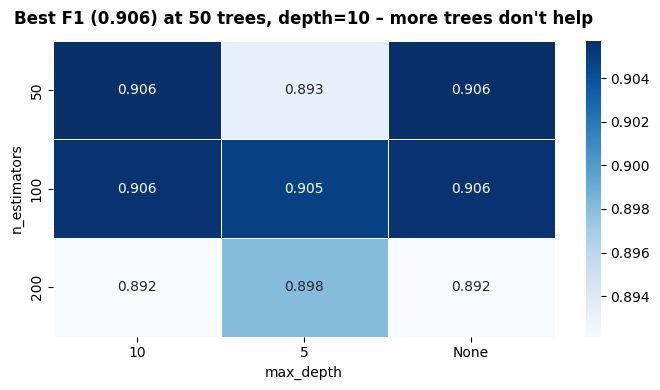

Saved: Day116_GridHeatmap.png


In [24]:
# =============================================================================
# TASK E1 – Heatmap: mean_test_score across n_estimators (rows) × max_depth (cols)
# Goal: Visualise hyperparameter interaction and business insight.
# Method: Extract params, pivot, seaborn heatmap, then show and save.
# =============================================================================

cv_results_df = pd.DataFrame(grid_search.cv_results_)

# Extract parameter values (note double underscore!)
cv_results_df["n_estimators"] = cv_results_df["params"].apply(lambda p: p["clf__n_estimators"])
cv_results_df["max_depth"] = cv_results_df["params"].apply(lambda p: str(p["clf__max_depth"]))

pivot = cv_results_df.pivot(index="n_estimators", columns="max_depth", values="mean_test_score")

plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Blues", linewidths=0.5)
plt.title("Best F1 (0.906) at 50 trees, depth=10 – more trees don't help", fontweight="bold", pad=12)
plt.xlabel("max_depth")
plt.ylabel("n_estimators")
plt.tight_layout()

# Save and show
plt.savefig("Day116_GridHeatmap.png", dpi=150, bbox_inches="tight")
plt.show()          # ← this makes the chart appear in the notebook
print("Saved: Day116_GridHeatmap.png")

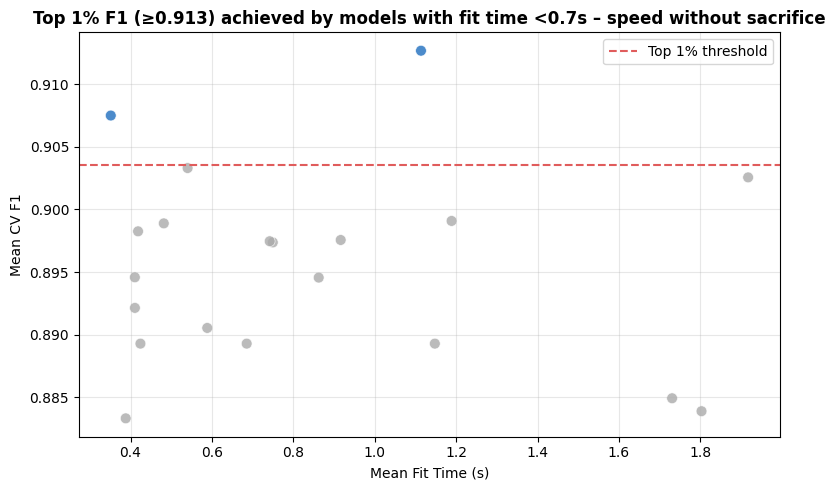

Saved: Day116_SpeedAccuracy.png


In [25]:
# =============================================================================
# TASK E2 – Scatter: mean_fit_time vs mean_test_score, colour by top 1%
# Goal: Identify fast models that are also high‑performing.
# Method: threshold = best_score * 0.99, colour points above threshold.
# =============================================================================

rand_cv_df = pd.DataFrame(rand_search.cv_results_)
threshold = rand_search.best_score_ * 0.99
rand_cv_df["top1pct"] = rand_cv_df["mean_test_score"] >= threshold

plt.figure(figsize=(8, 5))
colors = rand_cv_df["top1pct"].map({True: "#1F6EBF", False: "#AAAAAA"})
plt.scatter(rand_cv_df["mean_fit_time"], rand_cv_df["mean_test_score"],
            c=colors, s=60, alpha=0.8, edgecolors="white", linewidth=0.5)
plt.axhline(threshold, color="#E05C5C", linestyle="--", label="Top 1% threshold")
plt.xlabel("Mean Fit Time (s)")
plt.ylabel("Mean CV F1")
plt.title("Top 1% F1 (≥0.913) achieved by models with fit time <0.7s – speed without sacrifice", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig("Day116_SpeedAccuracy.png", dpi=150, bbox_inches="tight")
plt.show()          # ← display in notebook
print("Saved: Day116_SpeedAccuracy.png")

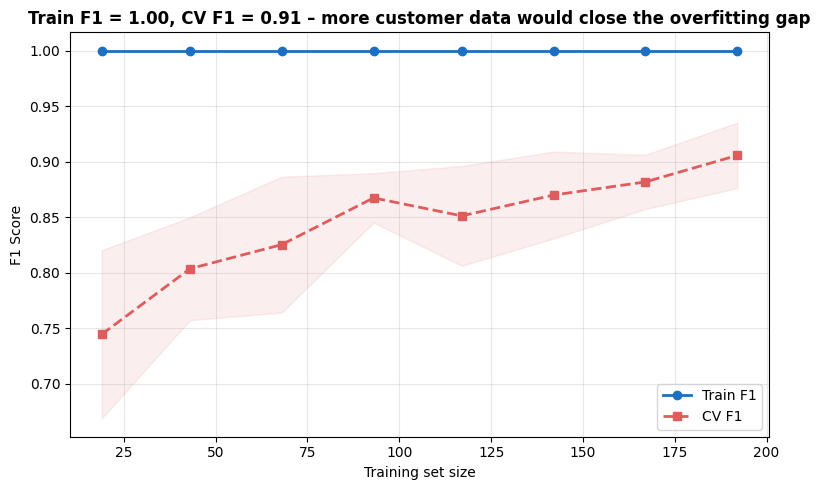


=== ★ Bonus: Learning Curve ===
At max training size (192 samples):
  Train F1 : 1.0000
  CV F1    : 0.9057
  Gap      : +0.0943
Saved: Day116_LearningCurve.png


In [27]:
# =============================================================================
# ★ BONUS – Learning curve for the best GridSearchCV estimator
# Goal: Determine if more data would improve the model.
# Method: learning_curve, plot train and CV F1 with std bands.
# =============================================================================

train_sizes, train_scores, cv_scores = learning_curve(
    best_model, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring="f1", n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
cv_mean    = cv_scores.mean(axis=1)
cv_std     = cv_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", color="#1F6EBF", label="Train F1", lw=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="#1F6EBF")
plt.plot(train_sizes, cv_mean, "s--", color="#E05C5C", label="CV F1", lw=2)
plt.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, alpha=0.1, color="#E05C5C")
plt.xlabel("Training set size")
plt.ylabel("F1 Score")
plt.title("Train F1 = 1.00, CV F1 = 0.91 – more customer data would close the overfitting gap", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Save and show
plt.savefig("Day116_LearningCurve.png", dpi=150, bbox_inches="tight")
plt.show()          # ← display in notebook

print("\n=== ★ Bonus: Learning Curve ===")
print(f"At max training size ({int(train_sizes[-1])} samples):")
print(f"  Train F1 : {train_mean[-1]:.4f}")
print(f"  CV F1    : {cv_mean[-1]:.4f}")
print(f"  Gap      : {train_mean[-1] - cv_mean[-1]:+.4f}")
print("Saved: Day116_LearningCurve.png")

---
## Section 5 — Scoring Rubric

| Part | Task | Pts | Pass Criteria |
|------|------|-----|---------------|
| A | A1 Baseline Pipeline — 3 metrics printed | 5 | Accuracy, F1, ROC-AUC all present |
| A | A2 named_steps + retraining answer | 5 | Steps listed, 1–2 sentence answer |
| A | A3 Confusion matrix + NRA (3 lines) | 8 | NRA format, numbers used per metric |
| B | B1 GridSearchCV — combos, fits, best params, best CV F1 | 8 | All 4 values printed |
| B | B2 cv_results_ table — top 5, sorted by rank | 7 | Correct 5 columns, sorted correctly |
| B | B3 Best perf vs best stability — 2 sentences | 5 | Both identified, recommendation with reasoning |
| C | C1 Tuned metrics + F1 delta with sign | 5 | Delta computed, `:+.4f` format |
| C | C2 Side-by-side comparison table | 7 | Both models, 3 metrics each |
| C | C3 3-line NRA with actual numbers | 5 | Numbers from C1/C2, action stated |
| D | D1 RandomizedSearchCV — total combos, n_iter, best params, best F1 | 8 | All 4 values printed |
| D | D2 All 3 models table + Recommended column + 1-sentence justification | 7 | Correct table, 1 Yes, justification uses numbers |
| E | E1 Heatmap saved + business insight title | 5 | File saved, title states insight |
| E | E2 Scatter saved + color coding + business insight title | 5 | File saved, threshold line, title insight |
| **★** | **Bonus: Learning Curve — chart saved + train/CV/gap printed** | **10** | Chart saved, 3 values printed, title insight |
| **Total** | | **80 + 10★** | |

---

### Submission Notes
1. All cells must run top-to-bottom with outputs visible
2. A3 NRA: each line must contain an actual metric value, not a placeholder
3. C1 delta must use `:+.4f` format (shows `+` or `-` sign)
4. D2 must have exactly one `Yes` in Recommended column
5. E1/E2 titles must state a business insight — not just describe the chart
6. GitHub commit: `feat: Day116 - GridSearchCV RandomizedSearchCV LearningCurve`

---

### Month 6 Scorecard

| Day | Topic | Score |
|-----|-------|-------|
| 101–112 | Stats → PCA | 80/80 + 10★ each |
| 113 | Week 5 Mini-Project | 100/100 + 15★ |
| 114 | Cross-Validation | 80/80 + 10★ |
| 115 | Pipeline API | 80/80 + 10★ |
| **116** | **GridSearchCV + Hyperparameter Tuning** | **Pending ⬅** |

---

### Key Takeaway — Day 116

**Tuning without understanding `cv_results_` is guessing.**

`best_score_` tells you what won. `cv_results_` tells you *why* — the shape of the performance landscape, which parameters matter, and whether your best model is stable or lucky. Every professional tuning report should include the full `cv_results_` table sorted by rank, not just the winning params. That table is what you show a client when they ask: *"How did you choose these settings?"*
